In [1]:
from graphs import * 
from utils import * 

In [2]:
def count_cross_edges(edges, partA, partB):
    """
    Count how many edges connect nodes from partA to nodes from partB.
    
    Parameters:
        edges (list of tuple): list of (u, v) edges
        partA (list or set): nodes in partition A
        partB (list or set): nodes in partition B
    
    Returns:
        int: number of crossing edges
    """
    setA = set(partA)
    setB = set(partB)
    count = 0
    
    for u, v in edges:
        if (u in setA and v in setB) or (u in setB and v in setA):
            count += 1
    
    return count

def graph_connectivity(n, graphs):

    graph_qubit = [i for i in range(n)]

    graph_conn = []

    for Gi in graphs:

        no_conn = 0
        for i in range(1,n):

            partA = graph_qubit[:i]
            partB = graph_qubit[i:]
            # print(partA,partB)
            no_conn += count_cross_edges(Gi.edges, partA, partB)
        
        graph_conn.append(no_conn)

    return np.array(graph_conn, dtype = float)

In [3]:
butterfly_q4 = np.loadtxt('butterfly-vel-q4.txt')
butterfly_q5 = np.loadtxt('butterfly-vel-q5.txt')
butterfly_q6 = np.loadtxt('butterfly-vel-q6.txt')


conn_q4 = graph_connectivity(n=4,graphs=Q4_graph)
conn_q5 = graph_connectivity(n=5,graphs=Q5_graph)
conn_q6 = graph_connectivity(n=6,graphs=Q6_graph)


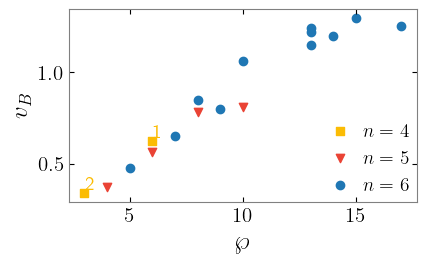

In [4]:
fig, ax = plt.subplots(figsize=(4.5,2.5))


ax.scatter(conn_q4, butterfly_q4, marker = 's',color = '#FBBC04',label = '$n=4$')
ax.scatter(conn_q5, butterfly_q5, marker = 'v', color = '#EA4335',label = '$n=5$')
ax.scatter(conn_q6, butterfly_q6, marker = 'o', color = 'tab:blue',label = '$n=6$')

textfont = {'family':'Calibri'}

for i in range(len(conn_q4)):
    ax.text(conn_q4[i] + 0.02, 
            butterfly_q4[i] + 0.02, 
            s=f'{i + 1}',
            color =  '#FBBC04',
            fontsize=14, 
            fontdict=textfont)


for spine in ax.spines.values():
    spine.set_edgecolor('gray')

plt.tick_params(top=True, left=True, right=True, bottom=True,
               direction="in", axis='both', which='both', 
               labelsize=15, color='k')

font2 = {'family':'serif', 'color':'black', 'size':18}
plt.ylabel(r"$v_B$", fontdict=font2)
plt.xlabel(r"$\wp$", fontdict=font2)

# Modified legend placement
plt.legend(
    fontsize=14,  # Slightly smaller font for external legend
    ncol=1,  # Fewer columns for vertical space
    loc='lower right', 
    # bbox_to_anchor=(1.02, 0.9),  # Positions legend outside axes
    frameon=False,
    borderaxespad=0.,  # Removes padding between axes and legend
    handletextpad=0.2
)

plt.show()